# 시군구별 고령화율 — KOSIS 데이터

KOSIS 주민등록인구 데이터에서 시군구별 65세 이상 인구와 전체 인구를 구해  
2019–2023 고령화율을 계산하고 `aging_rate_2019_2023.csv`로 저장

## 1. 환경 설정

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

KOSIS_CSV = './Kosis_고령화율_데이터/101_DT_1B040M5_20260524021414.csv'
OUTPUT_CSV = 'aging_rate_2019_2023.csv'

# KOSIS 연령 코드 — 65세 이상
AGE_65PLUS = [280, 310, 330, 340]  # 65-69, 70-74, 75-79, 80세 이상

## 2. KOSIS 데이터 로드

In [2]:
df_raw = pd.read_csv(KOSIS_CSV, encoding='euc-kr')

print(df_raw.shape)
df_raw.head()

(33480, 9)


,[A]행정구역(시군구)별,행정구역(시군구)별,[SBB]성별,성별,[YRE]연령별,연령별,시점,주민등록연앙인구[명],Unnamed: 8
0,0,전국,0,계,0,계,2019 년,51337423.5,NaN
1,0,전국,0,계,0,계,2020 년,51349259.0,NaN
2,0,전국,0,계,0,계,2021 년,51333252.5,NaN
3,0,전국,0,계,0,계,2022 년,51259149.5,NaN
4,0,전국,0,계,0,계,2023 년,51145884.5,NaN


## 3. 시군구 단위로 필터링

행정구역 코드가 **5자리**인 행만 남기기 (2자리=시도, 5자리=시군구)

In [3]:
code_col = '[A]행정구역(시군구)별'
name_col = '행정구역(시군구)별'

df_sgg = df_raw[df_raw[code_col].astype(str).str.len() == 5].copy()

print(f'전체 {len(df_raw):,}행 → 시군구 {len(df_sgg):,}행')
df_sgg[[code_col, name_col]].drop_duplicates().head()

전체 33,480행 → 시군구 31,320행


,[A]행정구역(시군구)별,행정구역(시군구)별
240,11010,종로구
360,11020,중구
480,11030,용산구
600,11040,성동구
720,11050,광진구


## 4. 인구 추출

- 전체 인구: 성별=계(0), 연령=계(0)
- 65세 이상: 성별=계(0), 65세 이상 연령 코드 합산

In [4]:
pop_col = '주민등록연앙인구[명]'

# 전체 인구
df_total = df_sgg[
    (df_sgg['[SBB]성별'] == 0) &
    (df_sgg['[YRE]연령별'] == 0)
][[code_col, name_col, '시점', pop_col]].copy()

df_total.columns = ['SGG_CODE', 'SGG_NM', '시점', '전체인구']
df_total['year'] = df_total['시점'].str[:4].astype(int)
df_total = df_total.drop(columns='시점')

# 65세 이상 인구
df_65 = df_sgg[
    (df_sgg['[SBB]성별'] == 0) &
    (df_sgg['[YRE]연령별'].isin(AGE_65PLUS))
][[code_col, name_col, '시점', pop_col]].copy()

df_65.columns = ['SGG_CODE', 'SGG_NM', '시점', '인구수']
df_65['year'] = df_65['시점'].str[:4].astype(int)
df_65 = df_65.drop(columns='시점')

df_65_sum = df_65.groupby(['SGG_CODE', 'SGG_NM', 'year'], as_index=False)['인구수'].sum()
df_65_sum = df_65_sum.rename(columns={'인구수': '65세이상인구'})

print('전체 인구:')
print(df_total.head())
print('\n65세 이상 인구:')
print(df_65_sum.head())

전체 인구:
     SGG_CODE SGG_NM      전체인구  year
240     11010    종로구  146603.0  2019
241     11010    종로구  144865.5  2020
242     11010    종로구  142767.0  2021
243     11010    종로구  140477.0  2022
244     11010    종로구  138501.0  2023

65세 이상 인구:
   SGG_CODE SGG_NM  year  65세이상인구
0     11010    종로구  2019  24829.5
1     11010    종로구  2020  25595.0
2     11010    종로구  2021  26336.0
3     11010    종로구  2022  26946.5
4     11010    종로구  2023  27661.5


## 5. 고령화율 계산

고령화율 = 65세 이상 인구 ÷ 전체 인구 × 100

In [5]:
df_merged = pd.merge(df_total, df_65_sum, on=['SGG_CODE', 'SGG_NM', 'year'])
df_merged['고령화율'] = (df_merged['65세이상인구'] / df_merged['전체인구'] * 100).round(2)

df_2023 = df_merged[df_merged['year'] == 2023].sort_values('고령화율', ascending=False)
cols = ['SGG_CODE', 'SGG_NM', '전체인구', '65세이상인구', '고령화율']

print('2023년 고령화율 상위 10:')
print(df_2023[cols].head(10).to_string(index=False))
print('\n2023년 고령화율 하위 10:')
print(df_2023[cols].tail(10).to_string(index=False))

2023년 고령화율 상위 10:
 SGG_CODE SGG_NM    전체인구  65세이상인구  고령화율
    37320    의성군 49981.0  22429.0 44.88
    22520    군위군 23109.5  10179.0 44.05
    36350    고흥군 61327.5  26859.5 43.80
    38400    합천군 41385.5  17754.5 42.90
    36360    보성군 38007.0  15877.0 41.77
    37360    청도군 41350.5  17099.0 41.35
    37330    청송군 24122.0   9929.5 41.16
    37350    영덕군 34246.0  14090.5 41.14
    38350    남해군 41075.0  16775.0 40.84
    37340    영양군 15812.0   6437.5 40.71

2023년 고령화율 하위 10:
 SGG_CODE SGG_NM     전체인구  65세이상인구  고령화율
    31140    오산시 228893.0  26027.5 11.37
    38112    성산구 246160.5  27512.5 11.18
    25040    유성구 360468.0  40265.5 11.17
    31150    시흥시 514060.5  57035.5 11.10
    24050    광산구 397801.0  43082.5 10.83
    29010    세종시 384276.5  41265.0 10.74
    26040     북구 217189.0  22396.5 10.31
    34012    서북구 399121.0  40801.5 10.22
    31240    화성시 925102.5  93048.0 10.06
    31014    영통구 360320.5  31103.0  8.63


## 6. 시각화

2023년 시군구별 고령화율 분포

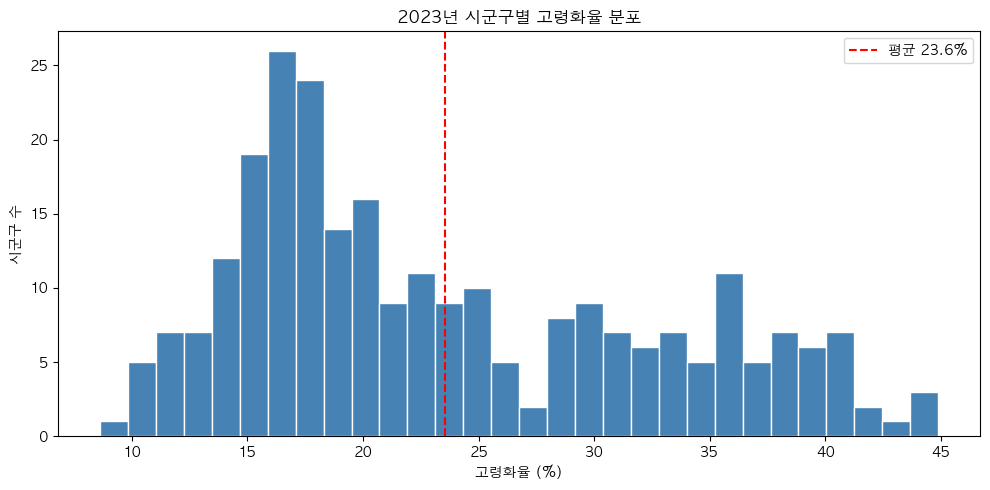

평균: 23.6%
최고: 44.9% (의성군)
최저: 8.6% (영통구)


In [6]:
mean_rate = df_2023['고령화율'].mean()
top_row = df_2023.iloc[0]
bottom_row = df_2023.iloc[-1]

plt.figure(figsize=(10, 5))
plt.hist(df_2023['고령화율'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(mean_rate, color='red', linestyle='--', label=f'평균 {mean_rate:.1f}%')
plt.xlabel('고령화율 (%)')
plt.ylabel('시군구 수')
plt.title('2023년 시군구별 고령화율 분포')
plt.legend()
plt.tight_layout()
plt.show()

print(f'평균: {mean_rate:.1f}%')
print(f'최고: {top_row["고령화율"]:.1f}% ({top_row["SGG_NM"]})')
print(f'최저: {bottom_row["고령화율"]:.1f}% ({bottom_row["SGG_NM"]})')

## 7. CSV 저장

In [7]:
df_merged.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print(df_merged.shape)
df_merged.head()

(1305, 6)


,SGG_CODE,SGG_NM,전체인구,year,65세이상인구,고령화율
0,11010,종로구,146603.0,2019,24829.5,16.94
1,11010,종로구,144865.5,2020,25595.0,17.67
2,11010,종로구,142767.0,2021,26336.0,18.45
3,11010,종로구,140477.0,2022,26946.5,19.18
4,11010,종로구,138501.0,2023,27661.5,19.97
